# Comparison retro vs forecast 2025-2026
1. Used flood retro historical data as a baseline (retro = historical)
2. load 2 forecast files (202507 and 202607) and flod retro + clean tambon geojson

## Load data
- retro
    historical = `monthly-flood-risk-area.csv`
- forecast
    July 2025 = `202507FloodForecast_6month.xlsx`
    July 2026 = `202607FloodForecast_6month.xlsx`

In [52]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

FORECAST_DIR = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/Flood Forecast 6 month')
RETRO_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/monthly-flood-risk-area.csv')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/TH_TAMBON_json/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')
YEARS = [2025, 2026]

forecasts = {year: pd.read_excel(FORECAST_DIR / f'{year}07FloodForecast_6month.xlsx') for year in YEARS}
retro = pd.read_csv(RETRO_PATH)
shapes = gpd.read_file(SHAPE_PATH)

for year in YEARS:
    print(f'{year}07 rows:', len(forecasts[year]))
    print(f'{year}07 unique tambons:', forecasts[year]['TAMBON_IDN'].nunique())
print('Retro rows:', len(retro))
print('Retro unique tambons:', retro['GEOCODE'].nunique())
print('Tambon polygons:', len(shapes))

202507 rows: 44328
202507 unique tambons: 7387
202607 rows: 44328
202607 unique tambons: 7387
Retro rows: 27023
Retro unique tambons: 6435
Tambon polygons: 7425


## Check data
- 3 datasets, different schema — check fields before transforming
- forecast (2025 / 2026): 6 months, `TYPE_E` (norisk / flood risk / flashflood), tambon `200701` duplicated per month
- retro: 12 months, `COUNT 17 YEAR` (flood occurrences in 17 yrs), Thai `RISK` labels

In [53]:
for year in YEARS:
    df = forecasts[year]
    dup = df.loc[df.duplicated(['TAMBON_IDN', 'MONTH']), 'TAMBON_IDN'].unique()
    print(f'=== {year}07 ===')
    print('months:', sorted(df['MONTH'].unique()),
          '| unique tambons:', df['TAMBON_IDN'].nunique(),
          '| dup tambon in a month:', list(dup) if len(dup) else '-')
    print(df['TYPE_E'].value_counts().to_string())
    print()


print('=== retro ===')
print('months:', sorted(retro['Month'].unique()), '| unique tambons:', retro['GEOCODE'].nunique())
print('COUNT 17 YEAR range:', retro['COUNT 17 YEAR'].min(), '-', retro['COUNT 17 YEAR'].max())
print(retro['RISK'].value_counts().to_string())

=== 202507 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | dup tambon in a month: [np.int64(200701)]
TYPE_E
norisk        38862
flood risk     4510
flashflood      956

=== 202607 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | dup tambon in a month: [np.int64(200701)]
TYPE_E
norisk        39850
flood risk     3689
flashflood      789

=== retro ===
months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 6435
COUNT 17 YEAR range: 1 - 14
RISK
เสี่ยงต่ำ        18105
เสี่ยงปานกลาง     6652
เสี่ยงสูง         2266


## Harmonize
- give all 3 datasets the same join key `CODE` (6-digit string) to match shapes
- forecast: relabel `inundation` -> `flood risk` (older files) + `CODE` from `TAMBON_IDN`
- retro: `CODE` from `GEOCODE`

In [54]:
for df in forecasts.values():
    df['TYPE_E'] = df['TYPE_E'].replace({'inundation': 'flood risk'})
    df['CODE'] = df['TAMBON_IDN'].astype(str)

retro['CODE'] = retro['GEOCODE'].astype(str)

print('forecast TYPE_E:', sorted(forecasts[2026]['TYPE_E'].unique()))
print('retro CODE sample:', retro['CODE'].head(3).tolist())

forecast TYPE_E: ['flashflood', 'flood risk', 'norisk']
retro CODE sample: ['120501', '120503', '120504']


## Check join key — CODE vs ADM3_PCODE
- compare each dataset's `CODE` against shapes (cut `TH` prefix)
- how many match, which are orphan (in data but not in shapes)

In [55]:
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')
shape_codes = set(shapes['CODE'])

sources = {**{f'{y}07': forecasts[y] for y in YEARS}, 'retro': retro}
orphan_codes = set()
for name, df in sources.items():
    codes = set(df['CODE'])
    orphans = sorted(codes - shape_codes)
    orphan_codes |= set(orphans)
    print(f'{name:8} matched: {len(codes & shape_codes):5} | orphan: {orphans}')

202507   matched:  7381 | orphan: ['201201', '401050', '530407', '630191', '810150', '860805']
202607   matched:  7381 | orphan: ['201201', '401050', '530407', '630191', '810150', '860805']
retro    matched:  6433 | orphan: ['401050', '630191']


## Fix mismatch
- forecast orphans are the same 6 codes every issue; retro orphans (`401050`, `630191`) are a subset
- remap each to the nearest tambon in the same amphoe (same method as `forecast-season` / `retro_risk`)
- one `remap` dict fixes both forecast and retro

In [56]:
def nearest_shape_code(row):
    same_amphoe = shapes.loc[(shapes['CODE'].str[:2] == row['CODE'][:2])
                             & (shapes['ADM2_TH'] == row['AMPHOE_T']), 'CODE']
    last2 = int(row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - last2))


orphans = forecasts[2026][forecasts[2026]['CODE'].isin(orphan_codes)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}

for df in forecasts.values():
    df['CODE'] = df['CODE'].replace(remap)
retro['CODE'] = retro['CODE'].replace(remap)

print('Re-mapped orphan codes (forecast + retro share the same fix):')
for old, new in remap.items():
    print(f'  {old} -> {new}')

Re-mapped orphan codes (forecast + retro share the same fix):
  201201 -> 200401
  401050 -> 401017
  530407 -> 530406
  630191 -> 630115
  810150 -> 810118
  860805 -> 860804


## Classify -> low / high
- collapse all 3 datasets to 2 levels so they compare directly
- retro: max of `COUNT 17 YEAR` per tambon -> 1-3 = `low`, 4-17 = `high`, no data = `low`
- forecast: take max across the 6 months (same as `forecast-season`) -> any month `flood risk` -> `high`, else = `low`
- build wide table: row = every shapes tambon, columns = retro / 2025 / 2026

In [57]:
SHAPE_CODE = shapes['CODE']


def to_risk(flag_by_code):
    return SHAPE_CODE.map(flag_by_code).eq(True).map({True: 'high', False: 'low'}).values


def take_max(df, type_label):
    return df.assign(flag=df['TYPE_E'].eq(type_label)).groupby('CODE')['flag'].any()


retro_high = retro.groupby('CODE')['COUNT 17 YEAR'].max().ge(4)

forecast_high = {y: take_max(forecasts[y], 'flood risk') for y in YEARS}

risk = pd.DataFrame({'retro': to_risk(retro_high),
                     2025: to_risk(forecast_high[2025]),
                     2026: to_risk(forecast_high[2026])
                    },
                    index=SHAPE_CODE.values)
risk.index.name = 'CODE'
print('Tambons:', len(risk))
risk.head()

Tambons: 7425


,retro,2025,2026
CODE,,,
100101,low,low,low
100102,low,low,low
100103,low,low,low
100104,low,low,low
100105,low,low,low


## count of risk (low / high)
- overall picture: how many tambons are `low` vs `high` in historical / 2025 / 2026

      retro  2025  2026
low    3584  4493  5245
high   3841  2932  2180


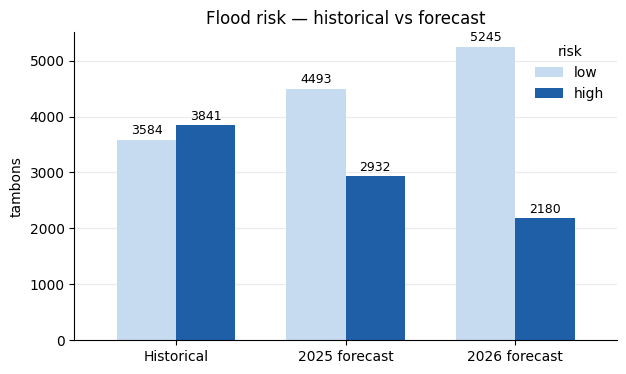

In [58]:
import matplotlib.pyplot as plt

RISK_COLORS = {'low': '#C6DBEF', 'high': '#1F5FA8'}

ORDER = ['retro', 2025, 2026]
LABELS = {'retro': 'Historical', 2025: '2025 forecast', 2026: '2026 forecast'}

counts = risk.apply(lambda c: c.value_counts()).reindex(['low', 'high'])[ORDER]
print(counts.to_string())

ax = counts.T.plot.bar(color=[RISK_COLORS['low'], RISK_COLORS['high']],
                       figsize=(7, 4), width=0.7, rot=0)
ax.set_xticklabels([LABELS[c] for c in ORDER])
ax.set_title('Flood risk — historical vs forecast')
ax.set_ylabel('tambons')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
ax.legend(title='risk', frameon=False)

## transition table
- historical = baseline; one row per transition `high -> high` / `high -> low` / `low -> high` / `low -> low`
- `% of historical group` = share of the historical `high` (or `low`) tambons that end in each 2026 class
- footer: percent change in high-risk tambons — 2026 vs historical (baseline) and 2026 vs 2025 (baseline)

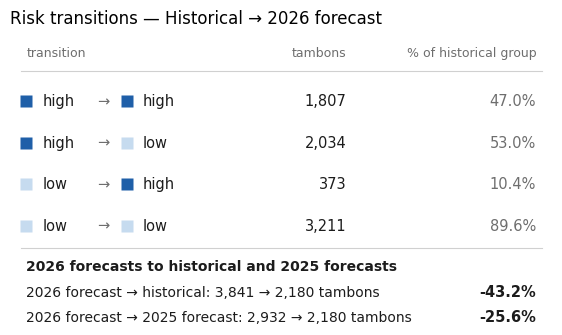

In [59]:
tab = pd.crosstab(risk['retro'], risk[2026])
hist_n = risk['retro'].value_counts()
high_n = {c: int((risk[c] == 'high').sum()) for c in ORDER}

TRANSITIONS = [('high', 'high'), ('high', 'low'), ('low', 'high'), ('low', 'low')]
chg_hist = (high_n[2026] - high_n['retro']) / high_n['retro'] * 100
chg_2025 = (high_n[2026] - high_n[2025]) / high_n[2025] * 100

INK, MUTED, LINE = '#1c1c1c', '#6e6e6e', '#d0d0d0'
X_SW1, X_FROM, X_ARROW, X_SW2, X_TO = 0.03, 0.06, 0.16, 0.215, 0.245
X_N, X_PCT = 0.62, 0.97

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Risk transitions — {LABELS['retro']} → {LABELS[2026]}",
             loc='left', fontsize=12, pad=14)

ax.text(X_SW1, 0.95, 'transition', fontsize=9, color=MUTED)
ax.text(X_N, 0.95, 'tambons', fontsize=9, color=MUTED, ha='right')
ax.text(X_PCT, 0.95, '% of historical group', fontsize=9, color=MUTED, ha='right')
ax.plot([0.02, 0.98], [0.90, 0.90], color=LINE, lw=0.8)

for i, (frm, to) in enumerate(TRANSITIONS):
    y = 0.79 - i * 0.15
    n = int(tab.loc[frm, to])
    ax.plot(X_SW1, y, marker='s', ms=8, color=RISK_COLORS[frm], mec='none')
    ax.text(X_FROM, y, frm, fontsize=10.5, color=INK, va='center')
    ax.text(X_ARROW, y, '→', fontsize=10.5, color=MUTED, va='center')
    ax.plot(X_SW2, y, marker='s', ms=8, color=RISK_COLORS[to], mec='none')
    ax.text(X_TO, y, to, fontsize=10.5, color=INK, va='center')
    ax.text(X_N, y, f'{n:,}', fontsize=10.5, color=INK, ha='right', va='center')
    ax.text(X_PCT, y, f'{n / hist_n[frm] * 100:.1f}%', fontsize=10.5, color=MUTED,
            ha='right', va='center')

ax.plot([0.02, 0.98], [0.26, 0.26], color=LINE, lw=0.8)
ax.text(X_SW1, 0.18, '2026 forecasts to historical and 2025 forecasts', fontsize=10, color=INK, fontweight='bold')
for y, base, label in [(0.10, 'retro', f"2026 forecast → {LABELS['retro'].lower()}"),
                       (0.01, 2025, f'2026 forecast → {LABELS[2025]}')]:
    chg = chg_hist if base == 'retro' else chg_2025
    ax.text(0.03, y, f'{label}: {high_n[base]:,} → {high_n[2026]:,} tambons',
            fontsize=10, color=INK, va='center')
    ax.text(X_PCT, y, f'{chg:+.1f}%', fontsize=10.5, color=INK, fontweight='bold',
            ha='right', va='center')

## Maps — historical vs forecast
- 3 maps side by side: historical / 2025 / 2026 — `low` light blue, `high` dark blue

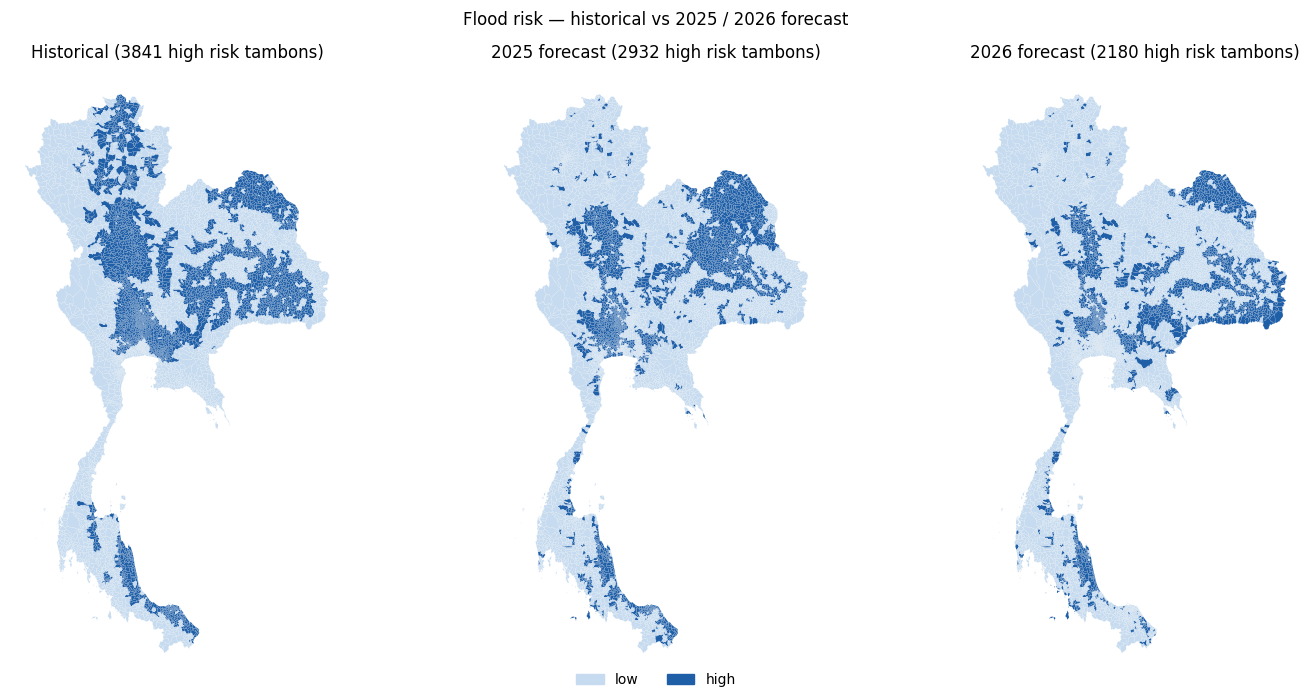

In [60]:
from matplotlib.patches import Patch


def plot_compare():
    fig, axes = plt.subplots(1, 3, figsize=(15, 7))
    for ax, col in zip(axes, ORDER):
        layer = shapes.assign(RISK=shapes['CODE'].map(risk[col]))
        layer.plot(ax=ax, color=layer['RISK'].map(RISK_COLORS), edgecolor='white', linewidth=0.05)
        ax.set_title(f"{LABELS[col]} ({int((risk[col] == 'high').sum())} high risk tambons)")
        ax.axis('off')
    fig.legend(handles=[Patch(color=RISK_COLORS[r], label=r) for r in ['low', 'high']],
               loc='lower center', ncol=2, frameon=False)
    fig.suptitle('Flood risk — historical vs 2025 / 2026 forecast', y=0.98)
    fig.tight_layout()


plot_compare()

## Output geojson
- one file: `RISK_RETRO` / `RISK_2025` / `RISK_2026` + `RETRO_2026` transition -> tableau

In [61]:
out = shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN', 'CODE', 'geometry']].copy()
for col, name in [('retro', 'RISK_RETRO'), (2025, 'RISK_2025'), (2026, 'RISK_2026')]:
    out[name] = out['CODE'].map(risk[col])
out['RETRO_2026'] = out['RISK_RETRO'].str.cat(out['RISK_2026'], sep=' -> ')
out = out.drop(columns='CODE')

output_file = OUTPUT_PATH / 'comparison_risk.geojson'
out.to_file(output_file, driver='GeoJSON', COORDINATE_PRECISION=8)
print(f'{output_file.name}: {len(out)} features ({output_file.stat().st_size / 1e6:.1f} MB)')

comparison_risk.geojson: 7425 features (8.7 MB)
